# 01 — Filter sensors to the study set

Apply three transparent rules to every registered sensor and record the decision. The study area is *strict Leeds* (a bounding box); indoor and test/experimental units are removed. Outputs: a full decision log and the clean study list, plus a kept-vs-excluded map.

**Note on counts:** the filter keeps 48 sensors by these rules. One of them (SL71 Kentmere) has no data folder on disk, so the next notebook combines 47. The 48 → 47 drop is expected, not an error.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # so `from src...` works from notebooks/
from src.config import *
import pandas as pd


df = pd.read_csv(DATA_DIR / "sensor_summary.csv")
print(df.shape)
df.head()

(68, 12)


,sensor_id,sensor_name,pa_id,lat,lon,location_type,last_modified,last_seen,pm25_a,pm25_b,time_stamp_a,time_stamp_b
0,1,SL71 - Kentmere,51535,53.825920,-1.468594,outdoor,2024-09-05 11:37:29,2026-05-10 14:31:10,1,1,2026-05-10 14:31:10,2026-05-10 14:31:10
1,2,SEE(#2) - UPSURGE - Crossley St,117263,53.930550,-1.389377,indoor,2024-05-09 17:29:19,2024-04-28 02:11:15,0,0,2024-04-28 02:11:15,2024-04-28 02:11:15
2,3,SL050 - Bardsey,131651,53.889965,-1.439765,outdoor,2023-10-18 13:47:20,2026-07-06 06:09:40,0,0,2026-07-06 06:09:40,2026-07-06 06:09:40
3,4,SL055 - Temple Newsam,131655,53.785603,-1.455717,outdoor,2023-08-15 16:20:29,2025-02-17 00:40:07,14,17,2025-02-17 00:40:07,2025-02-17 00:40:07
4,5,SL018 East Ardsley A650,132055,53.725370,-1.550685,outdoor,2022-09-26 15:48:26,2026-01-26 09:17:57,33,28,2026-01-26 09:17:57,2026-01-26 09:17:57


### Assess every sensor against three rules
Geographic (inside the Leeds box, by coordinates not name), indoor, and not-a-genuine-field-monitor.

In [2]:
def assess(row):
    """Return a string of exclusion reasons (empty string = keep)."""
    name = str(row["sensor_name"])
    low  = name.lower()
    loc  = str(row["location_type"]).lower()
    lat, lon = row["lat"], row["lon"]
    reasons = []

    # Rule 1 — geographic: inside the strict-Leeds box, judged by COORDINATES
    inside = (LEEDS_BOX["lat_min"] < lat < LEEDS_BOX["lat_max"]
              and LEEDS_BOX["lon_min"] < lon < LEEDS_BOX["lon_max"])
    if not inside:
        reasons.append("outside Leeds area")

    # Rule 2 — indoor: the project is about outdoor air quality
    if loc == "indoor" or "inside" in low:
        reasons.append("indoor")

    # Rule 3 — not a genuine field monitor (test rigs, undeployed units)
    if "not deployed" in low:
        reasons.append("not deployed")
    if any(k in low for k in ["upsurge", "data test", "experimental",
                              "highspeed", "unassigned"]):
        reasons.append("test/experimental")

    return "; ".join(reasons)

df["exclude_reason"] = df.apply(assess, axis=1)
df["keep"] = df["exclude_reason"] == ""
print(f"Keep: {df['keep'].sum()}   Exclude: {(~df['keep']).sum()}")

Keep: 48   Exclude: 20


### Review the excluded list (the audit step)

In [3]:
df[~df["keep"]][["sensor_name", "lat", "lon", "location_type", "exclude_reason"]] \
    .sort_values("exclude_reason")

,sensor_name,lat,lon,location_type,exclude_reason
10,SL047 (OAKLEA),53.890400,-1.438621,indoor,indoor
34,SL058 - SEE Building 10.102,53.825676,-1.587510,indoor,indoor
35,Ibadan Study OUTSIDE (SL052),53.888240,-1.430587,indoor,indoor
11,SL002 - NOT DEPLOYED,53.805830,-1.555835,indoor,indoor; not deployed
54,SL043 - NOT DEPLOYED,53.889942,-1.439613,indoor,indoor; not deployed
1,SEE(#2) - UPSURGE - Crossley St,53.930550,-1.389377,indoor,indoor; test/experimental
21,SL004 - UPSURGE - Crossley St,53.930702,-1.389783,indoor,indoor; test/experimental
36,SL059 - UPSURGE DATA TEST,53.805077,-1.554896,indoor,indoor; test/experimental
38,SL053 - UPSURGE - Crossley St,53.930454,-1.389116,indoor,indoor; test/experimental
41,SL049 - UPSURGE data test,53.826397,-1.588688,indoor,indoor; test/experimental


### Review the kept study set

In [4]:
kept = df[df["keep"]].sort_values("sensor_name")
print(f"Study set: {len(kept)} Leeds outdoor sensors")
kept[["sensor_name", "location_type", "lat", "lon", "last_seen"]]

Study set: 48 Leeds outdoor sensors


,sensor_name,location_type,lat,lon,last_seen
14,SL001 Sunnyview Terrace,outdoor,53.774956,-1.565842,2026-02-19 18:57:20
26,SL003 - Corn Exchange Cabinet,outdoor,53.796494,-1.540428,2025-02-22 00:01:37
25,SL005 Kirkstall Valley Primary,outdoor,53.808520,-1.586729,2026-02-06 11:27:41
46,SL006 - Primrose Hill Primary,outdoor,53.801888,-1.667109,2026-07-06 06:09:25
44,SL007 Ninelands Primary,outdoor,53.789272,-1.377445,2026-07-06 06:10:25
43,SL008 Westgate Primary,outdoor,53.903084,-1.703357,2026-07-06 06:10:48
48,SL009 - Roundhay Golf Club,outdoor,53.836400,-1.487316,2024-06-20 10:27:33
12,"SL011 - West End Grove, Horsforth",outdoor,53.838055,-1.655033,2026-07-06 06:10:21
51,"SL012 - Fountain Street, Morley",outdoor,53.742184,-1.606196,2026-04-13 06:45:31
7,SL015 - Garforth Main Street,outdoor,53.793552,-1.388243,2024-06-08 01:34:40


### Save the decision log and the clean study list

In [5]:
df[["sensor_id", "sensor_name", "location_type", "lat", "lon",
    "keep", "exclude_reason"]].to_csv(
    OUT_TABLES / "sensor_filter_decisions.csv", index=False)

kept[["sensor_id", "sensor_name", "location_type", "lat", "lon"]].to_csv(
    OUT_TABLES / "study_sensors.csv", index=False)

print("Saved:")
print("  outputs/tables/sensor_filter_decisions.csv  (all sensors, with reasons)")
print("  outputs/tables/study_sensors.csv            (the keepers)")

Saved:
  outputs/tables/sensor_filter_decisions.csv  (all sensors, with reasons)
  outputs/tables/study_sensors.csv            (the keepers)


### Map: kept vs excluded
A quick geographic check that the box did what we intended.

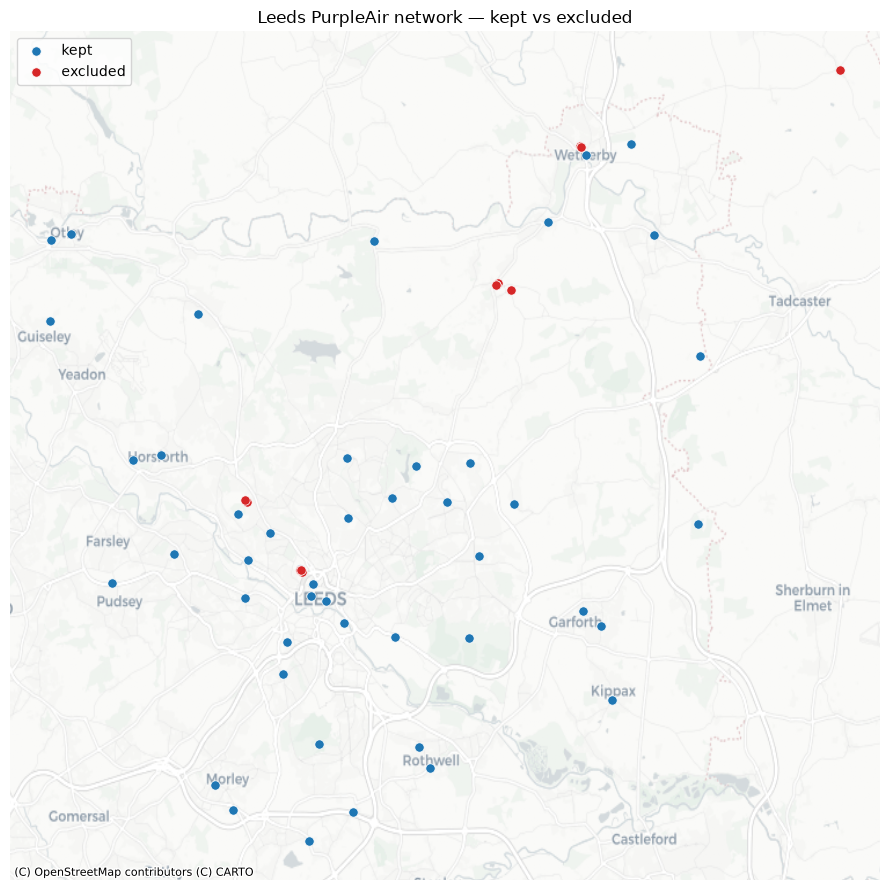

In [6]:
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np

near = df[(df["lat"].between(53.5, 54.1)) & (df["lon"].between(-2.0, -1.1))].copy()

# contextily basemaps use Web Mercator (EPSG:3857); convert lon/lat -> x/y inline
R = 6378137.0
near["x"] = np.radians(near["lon"]) * R
near["y"] = np.log(np.tan(np.pi/4 + np.radians(near["lat"])/2)) * R

fig, ax = plt.subplots(figsize=(9, 9))
for keep_flag, colour, label in [(True, "tab:blue", "kept"),
                                  (False, "tab:red", "excluded")]:
    sub = near[near["keep"] == keep_flag]
    ax.scatter(sub["x"], sub["y"], c=colour, s=45, label=label,
               edgecolor="white", linewidth=0.5, zorder=3)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off(); ax.legend()
ax.set_title("Leeds PurpleAir network — kept vs excluded")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "sensor_map_static.png", dpi=200)
plt.show()